In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/hour_cleaned.csv", parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()

print(f"Shape: {df.shape}")

Shape: (17379, 17)


In [2]:
# check overall distribution of target variable
print(df["cnt"].describe().round(2))

count    17379.00
mean       189.46
std        181.39
min          1.00
25%         40.00
50%        142.00
75%        281.00
max        977.00
Name: cnt, dtype: float64


### mean is more then median

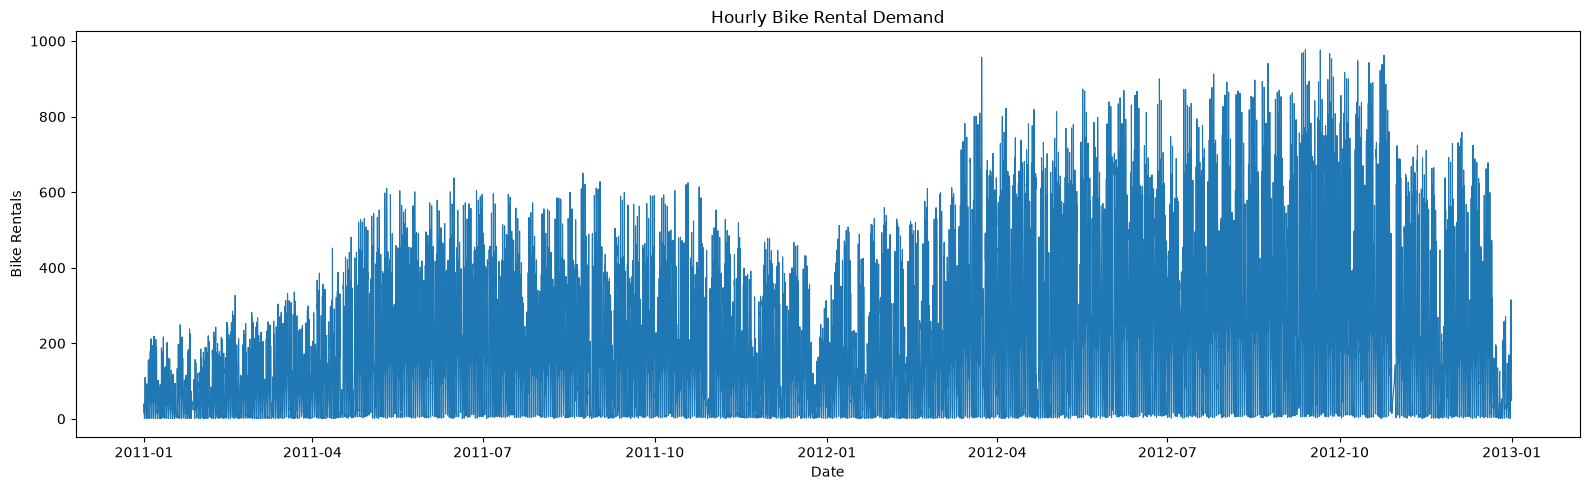

In [3]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["cnt"], linewidth=0.8)
plt.title("Hourly Bike Rental Demand")
plt.xlabel("Date")
plt.ylabel("Bike Rentals")
plt.tight_layout()
plt.show()


Demand shows substantial variation over the two-year period, with clear changes in both level and volatility. The series is not stationary by visual inspection alone, so we will formally test stationarity later.

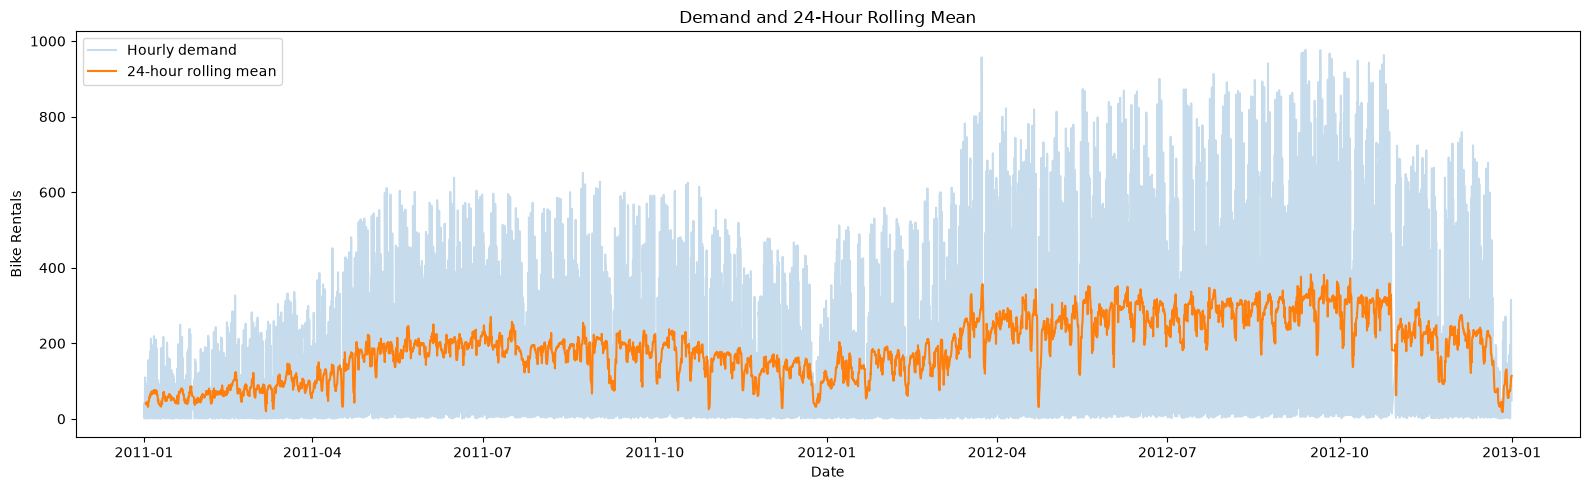

In [ ]:
# smooth the time series using a rolling window 24h
rolling_mean = df["cnt"].rolling(24).mean()
rolling_std = df["cnt"].rolling(24).std()

plt.figure(figsize=(16, 5))
plt.plot(df.index, df["cnt"], alpha=0.25, label="Hourly demand")
plt.plot(df.index, rolling_mean, label="24-hour rolling mean")
plt.title("Demand and 24-Hour Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Bike Rentals")
plt.legend()
plt.tight_layout()
plt.show()

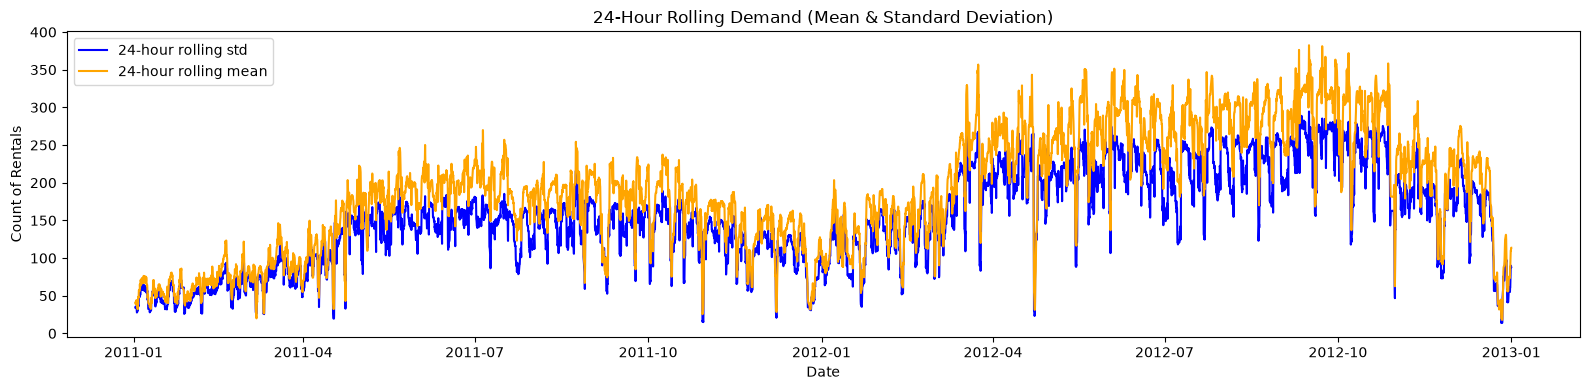

In [12]:
# check how demand varies over time using rolling iwndow 34h standard deviation
plt.figure(figsize=(16, 4))
plt.plot(df.index, rolling_std, label="24-hour rolling std", color="blue")
plt.plot(df.index, rolling_mean, label="24-hour rolling mean", color="orange")
plt.title("24-Hour Rolling Demand (Mean & Standard Deviation)")
plt.xlabel("Date")
plt.ylabel("Count of Rentals")
plt.legend()
plt.tight_layout()
plt.show()

The rolling mean and standard deviation show that demand and its variability change over time, suggesting a non-constant mean/variance structure.

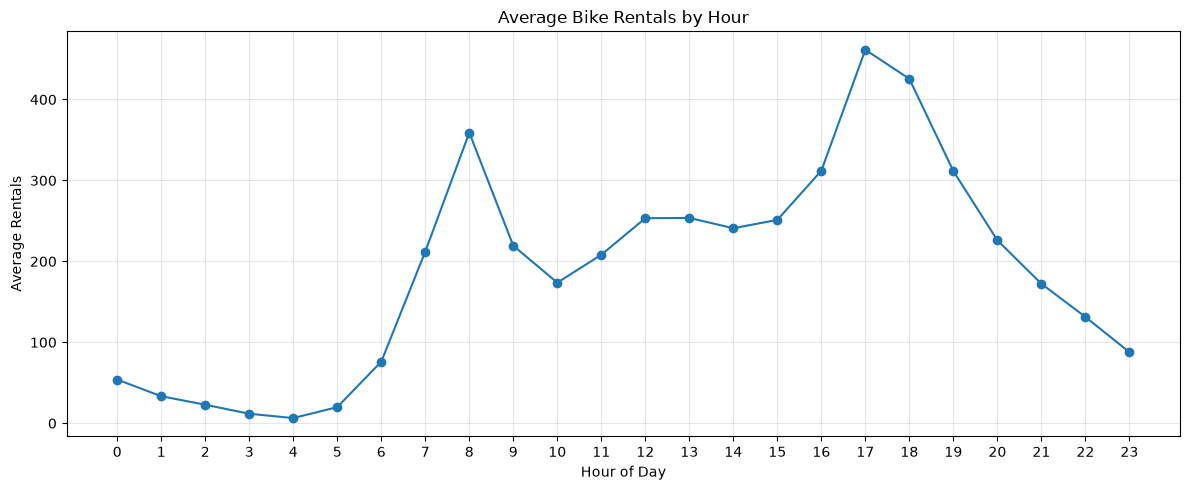

In [13]:
# average demand by hour
hourly_pattern = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Hourly demand has very strong daily seasonality. Demand peaks around 17:00–18:00 and falls to its lowest level around 04:00. This indicates a strong 24-hour seasonal cycle.

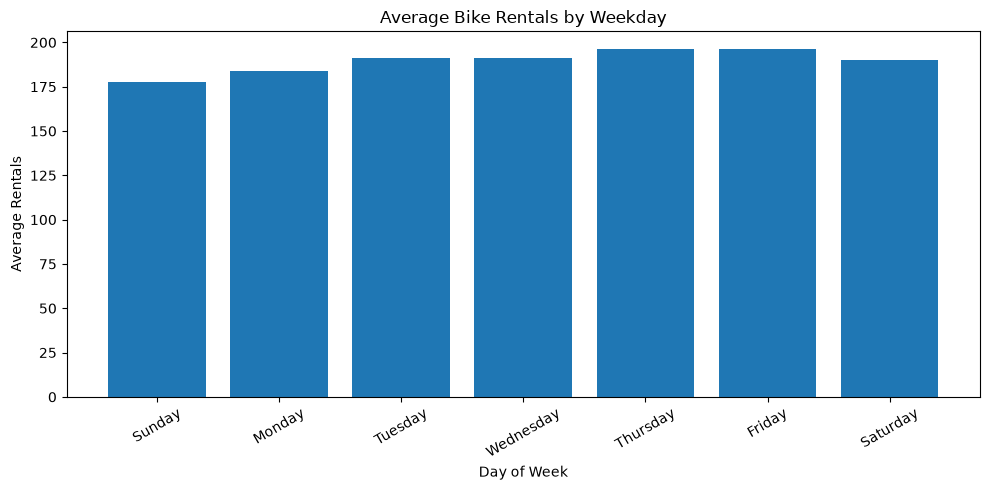

In [14]:
# weekly average demand by day of week
weekday_pattern = df.groupby("weekday")["cnt"].mean()

weekday_names = [
    "Sunday", "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday"
]

plt.figure(figsize=(10, 5))
plt.bar(weekday_names, weekday_pattern.values)
plt.title("Average Bike Rentals by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Rentals")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Weekday differences are relatively small compared with the strong hourly pattern. Thursday has the highest average demand, while Sunday has the lowest.

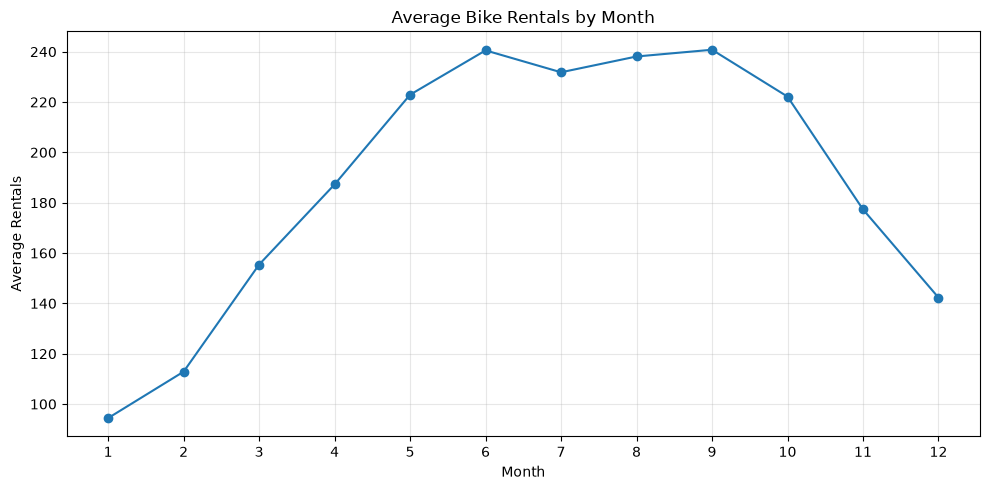

In [15]:
# avwerage demand by month
monthly_pattern = df.groupby("mnth")["cnt"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker="o")
plt.title("Average Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Demand varies substantially by month. Demand is lowest in January and generally increases toward summer and early autumn, indicating annual seasonal structure.

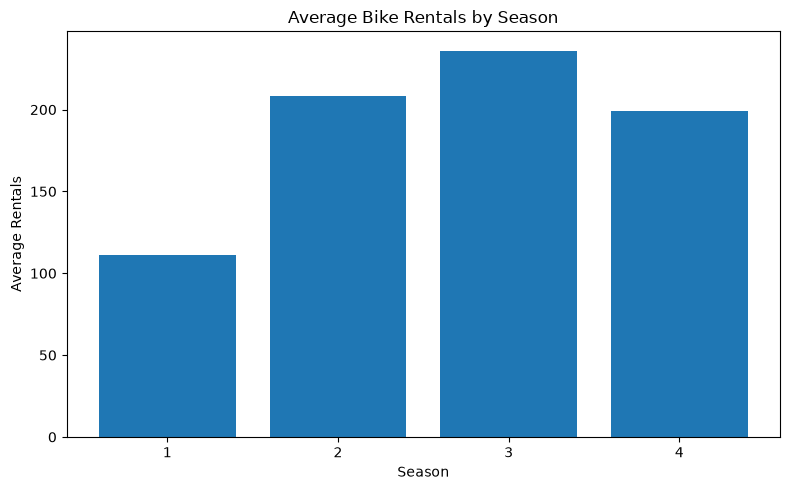

In [16]:
# accross 4 seasons
season_pattern = df.groupby("season")["cnt"].mean()

plt.figure(figsize=(8, 5))
plt.bar(season_pattern.index.astype(str), season_pattern.values)
plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.tight_layout()
plt.show()

Season has a clear relationship with rental demand. Season 3 has the highest average demand, while Season 1 has the lowest.

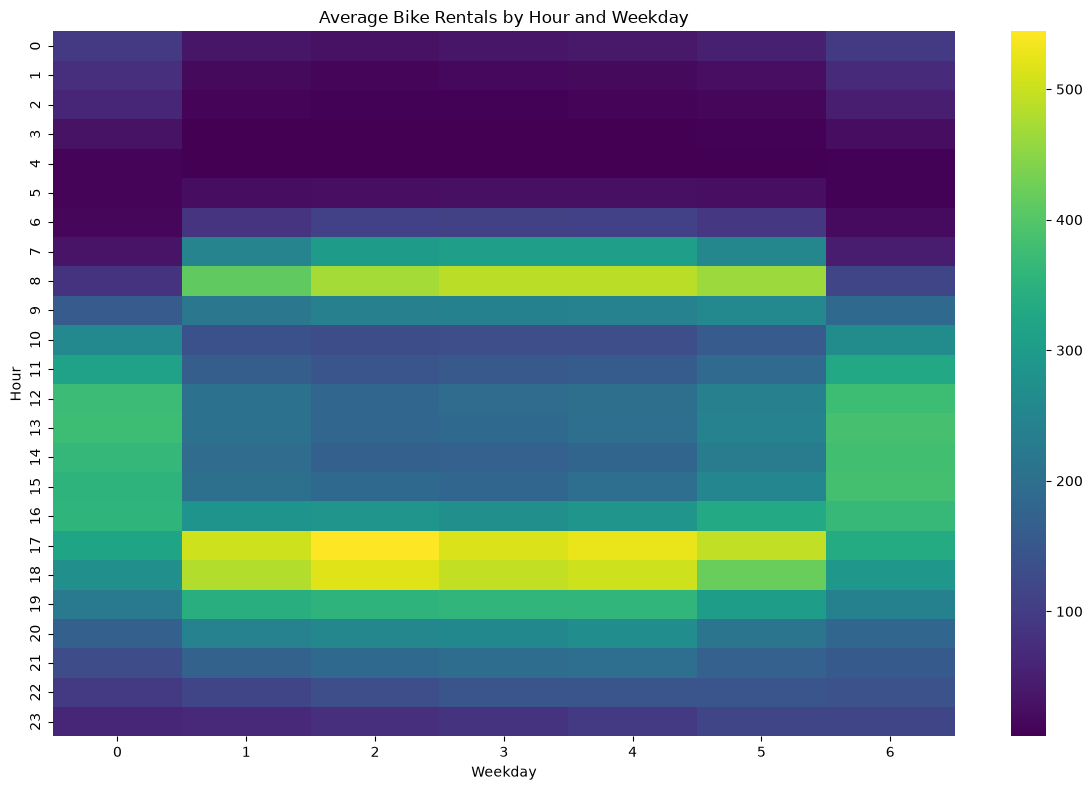

In [17]:
# Visualize how hourly demand changes across different days of the week
hour_weekday = df.pivot_table(
    values="cnt",
    index="hr",
    columns="weekday",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    hour_weekday,
    cmap="viridis",
    annot=False
)

plt.title("Average Bike Rentals by Hour and Weekday")
plt.xlabel("Weekday")
plt.ylabel("Hour")
plt.tight_layout()
plt.show()

The heatmap reveals that hourly demand patterns differ across weekdays. The combination of hour and weekday therefore provides useful temporal information for forecasting.

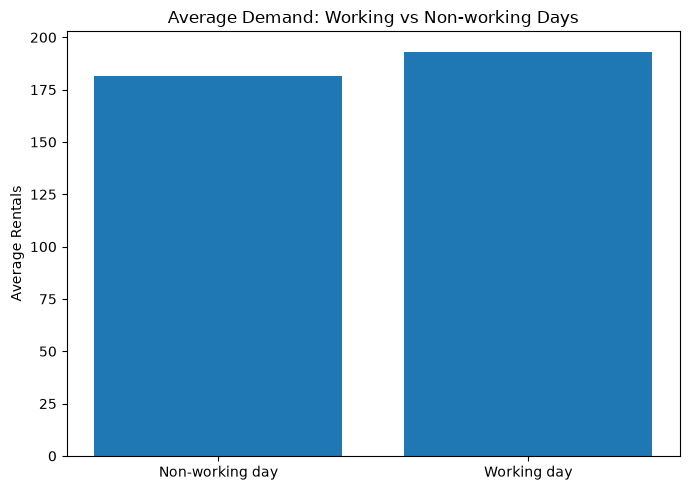

In [20]:
#  Determine whether bike rental demand differs between working days and non-working days.

workingday_pattern = df.groupby("workingday")["cnt"].mean()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Non-working day", "Working day"],
    workingday_pattern.values
)
plt.title("Average Demand: Working vs Non-working Days")
plt.ylabel("Average Rentals")
plt.tight_layout()
plt.show()

Working days have approximately 6.5% higher average demand than non-working days, suggesting that commuting behavior contributes to rental demand.

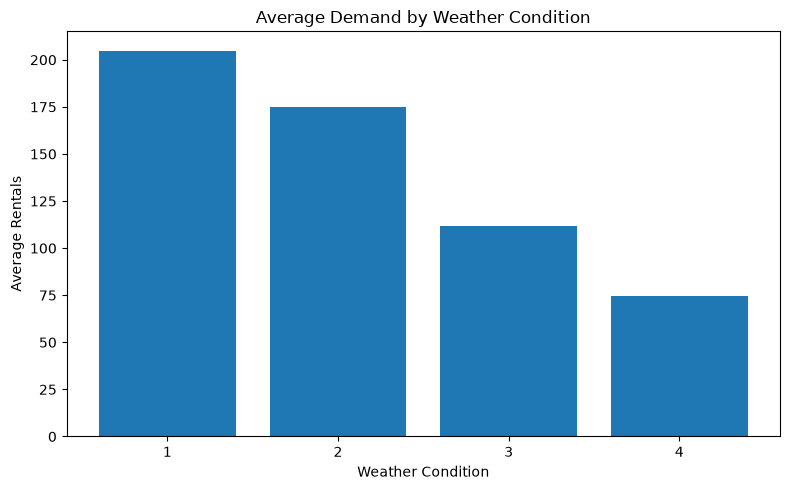

In [21]:
# Examine how weather conditions are associated with bike rental demand.

weather_pattern = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8, 5))
plt.bar(
    weather_pattern.index.astype(str),
    weather_pattern.values
)
plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Rentals")
plt.tight_layout()
plt.show()

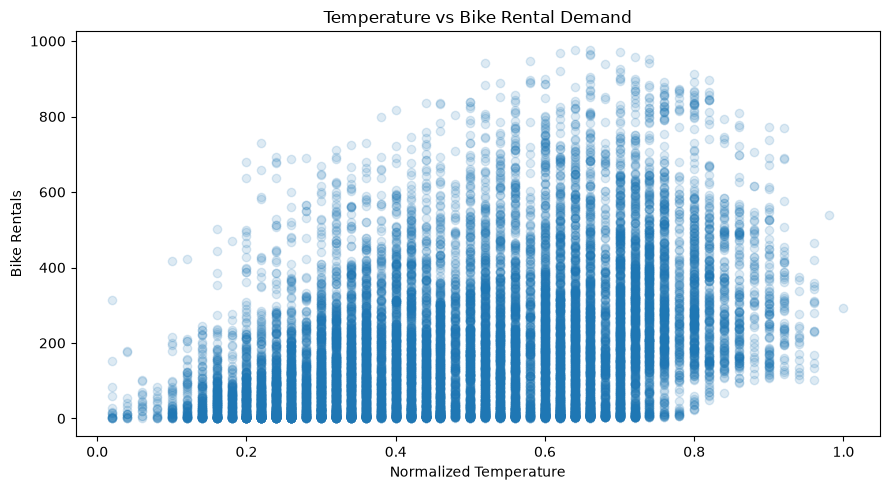

In [22]:
# Visualize the relationship between temperature and bike rental demand.

plt.figure(figsize=(9, 5))
plt.scatter(
    df["temp"],
    df["cnt"],
    alpha=0.15
)
plt.title("Temperature vs Bike Rental Demand")
plt.xlabel("Normalized Temperature")
plt.ylabel("Bike Rentals")
plt.tight_layout()
plt.show()

Temperature has a moderate positive relationship with rental demand. However, the relationship is not purely linear and may also reflect underlying seasonal effects.

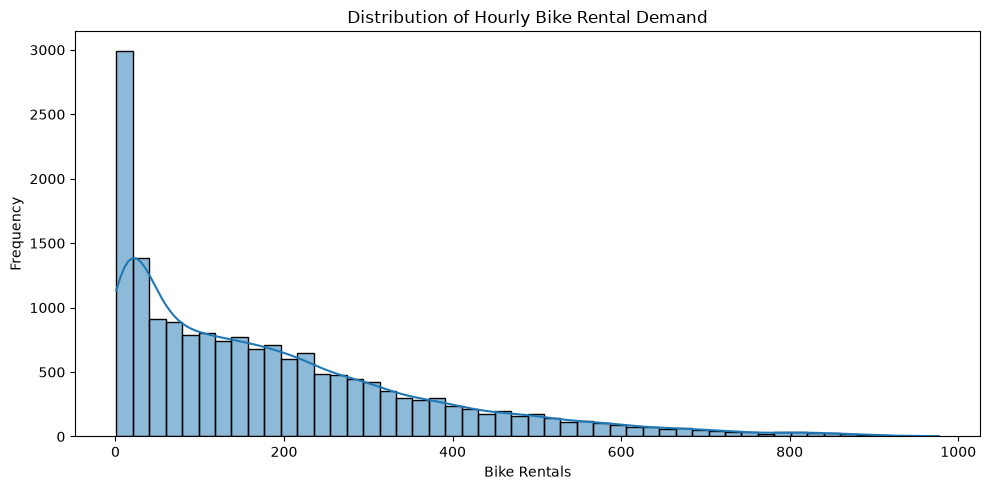

In [23]:
# Examine the distribution and skewness of the target variable.

plt.figure(figsize=(10, 5))
sns.histplot(df["cnt"], bins=50, kde=True)
plt.title("Distribution of Hourly Bike Rental Demand")
plt.xlabel("Bike Rentals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Rental demand is right-skewed (skewness ≈ 1.28), with most observations at relatively low-to-moderate demand and fewer observations at very high demand.

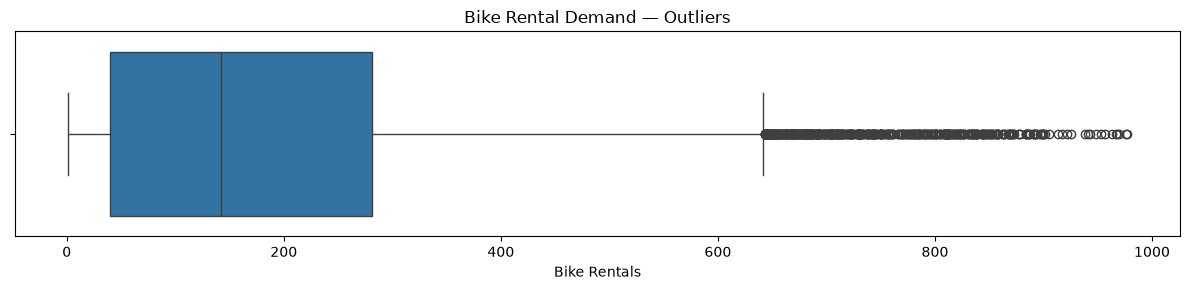

In [24]:
# Outliers
plt.figure(figsize=(12, 3))
sns.boxplot(x=df["cnt"])
plt.title("Bike Rental Demand — Outliers")
plt.xlabel("Bike Rentals")
plt.tight_layout()
plt.show()

Several high-demand observations exist, but they should not automatically be treated as errors. They may represent legitimate peak rental periods.

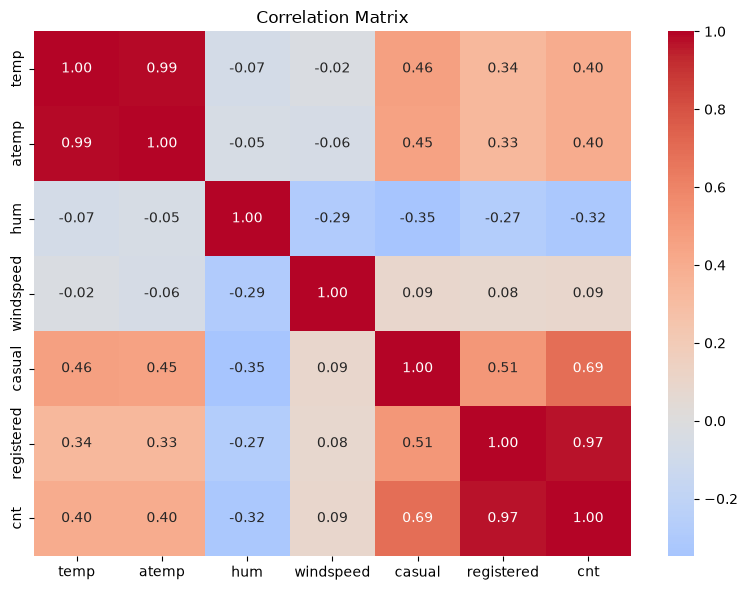

In [27]:
# Correlation
numeric_columns = [
    "temp", "atemp", "hum", "windspeed",
    "casual", "registered", "cnt"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Temperature and humidity show the strongest relationships with demand among the weather variables. `casual` and `registered` are highly correlated with `cnt` because they directly compose the target, so they will not be used as forecasting features.

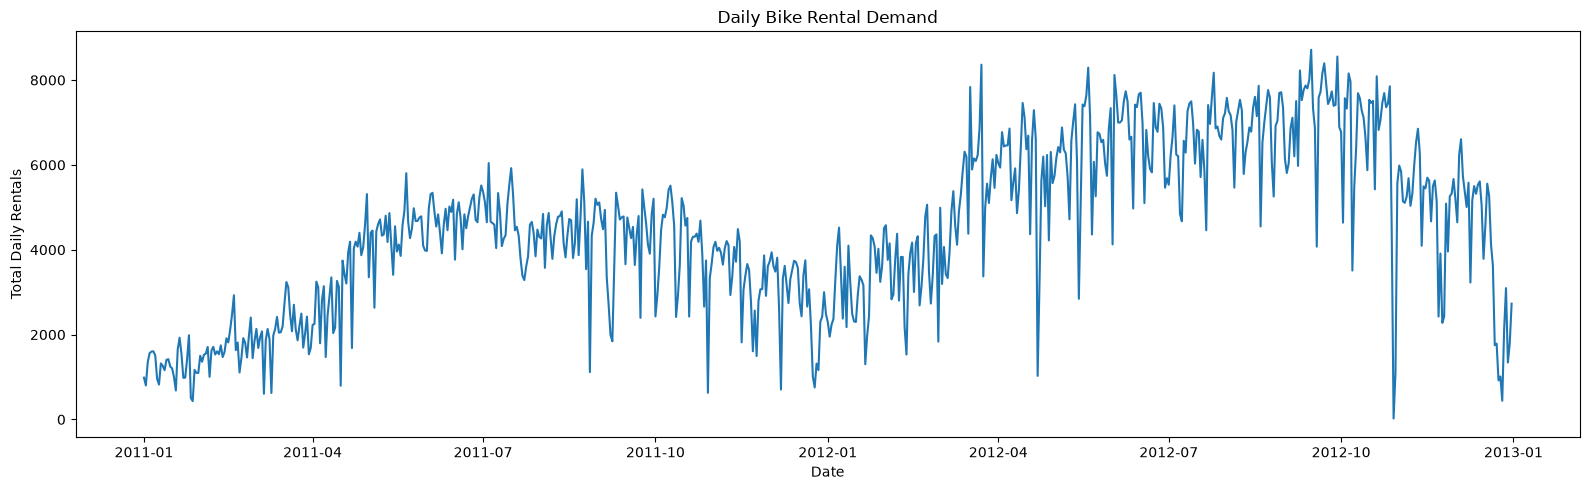

In [28]:
# daily demand
daily_demand = df["cnt"].resample("D").sum()

plt.figure(figsize=(16, 5))
plt.plot(daily_demand)
plt.title("Daily Bike Rental Demand")
plt.xlabel("Date")
plt.ylabel("Total Daily Rentals")
plt.tight_layout()
plt.show()

Daily aggregation confirms substantial variation in overall demand and makes the longer-term trend easier to observe than the raw hourly series.

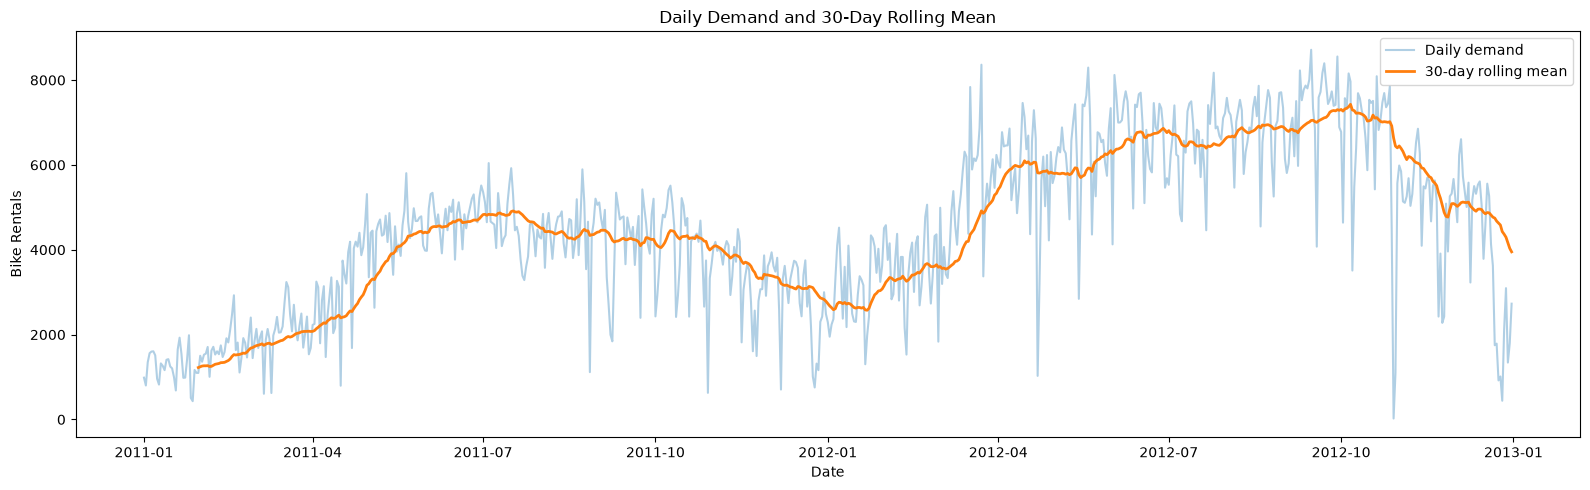

In [29]:
# Smooth daily demand to highlight the underlying long-term trend.

daily_rolling = daily_demand.rolling(30).mean()

plt.figure(figsize=(16, 5))
plt.plot(daily_demand, alpha=0.35, label="Daily demand")
plt.plot(daily_rolling, linewidth=2, label="30-day rolling mean")
plt.title("Daily Demand and 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Bike Rentals")
plt.legend()
plt.tight_layout()
plt.show()

The smoothed daily series makes the longer-term demand pattern clearer and suggests that demand changes across the two-year period rather than remaining at a constant level.